In [104]:
%load_ext autoreload 
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import nibabel as nib
import os 
opj = os.path.join
%matplotlib inline 
sub = 'sub-ht2'
import subprocess
import shutil
# Get everything ready
BIDS_dir = '/Users/marcusdaghlian/projects/pilot-clean-link/'
output_path = f'/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/{sub}'
if not os.path.exists(output_path):
    os.makedirs(output_path)
fs_dir = opj(BIDS_dir, 'derivatives', 'freesurfer')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Note on run-1; has 1 extra TR, so I have copied it, and chopped off the last tr
```bash
cp rsub-03_task-task-colbw_run-01_bold.nii rsub-03_task-task-colbw_run-01_boldFULL.nii
fslroi rsub-03_task-task-colbw_run-01_bold.nii rsub-03_task-task-colbw_run-01_bold.nii 0 90
rm rsub-03_task-task-colbw_run-01_bold.nii
gunzip rsub-03_task-task-colbw_run-01_bold.nii.gz
```

In [105]:
from dpu_mini.utils import *
def load_benson14_info(sub, fs_dir):
    ''' *no*
    '''
    sub_fs_dir = opj(fs_dir, sub, 'surf')    
    b14_dict = {}
    for p in ['eccen', 'angle', 'sigma', 'varea']:
        hemi_p = []
        for hemi in ['lh', 'rh']:
            b14_p_file = dag_find_file_in_folder(
                [hemi, p, 'benson14', '.mgz'],
                sub_fs_dir,
            )
            hemi_p.append(nib.load(b14_p_file).get_fdata().squeeze())   
        if p=='eccen':
            better_name = 'ecc'
        elif p=='angle':
            better_name = 'pol'
        elif p=='sigma':
            better_name = 'size_1'
        elif p=='varea':
            better_name = 'varea'
        b14_dict[better_name] = np.concatenate(hemi_p, axis=0)
    return b14_dict
b14_info = load_benson14_info(sub, fs_dir)

In [106]:
import os
opj = os.path.join
moco_folder = f'/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/{sub}'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if (f.endswith('bold.nii') and f.startswith('rsub')) ]
rfiles = [f for f in rfiles if 'accordion' not in f]
rfiles.sort()
print(rfiles)
print(len(rfiles))

['/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-01_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-02_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-03_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-04_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-05_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-06_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-07_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-ht2/rsub-ht2_color-task_sess-01_run-08_bold.nii',

In [4]:
# # os.system(f'cp {rfiles[0]} {rfiles[0].replace(".nii", "BU.nii")}')

# img = nib.load(rfiles[0])
# data = img.get_fdata()

# # Remove last volume along the 4th dimension
# data_trimmed = data[..., :-1]
# print(data_trimmed.shape)
# new_img = nib.Nifti1Image(data_trimmed, img.affine, img.header)
# nib.save(new_img, rfiles[0])

In [108]:


stest_dir = opj(output_path, 'test01')
if not os.path.exists(stest_dir):
    os.makedirs(stest_dir)
#     shutil.rmtree(stest_dir, )


fs_anat = opj(fs_dir, sub, 'mri', 'brain.mgz')
anat_ref = opj(stest_dir, 'anat_ref.nii.gz')
# Add the brain as anatomical ref
if True: #not os.path.exists(anat_ref):
    subprocess.run(
        ['mri_convert', fs_anat, anat_ref]
    )




mri_convert /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/anat_ref.nii.gz 
reading from /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz...
TR=0.00, TE=0.00, TI=0.00, flip angle=0.00
i_ras = (-1, 1.33046e-09, 0)
j_ras = (2.66092e-09, -8.52326e-09, -1)
k_ras = (0, 1, 7.0265e-09)
writing to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/anat_ref.nii.gz...


In [109]:
# Add the ROIs
b14_vol = opj(stest_dir, 'b14_vol.nii.gz')
ndil = 2
b14_vol_dil = opj(stest_dir, f'b14_vol{ndil}.nii.gz')
if not os.path.exists(b14_vol):
    cmd = ' '.join([
        f"mri_label2vol --temp {opj(fs_dir, sub, 'mri', 'orig.mgz')} ",
        f"--label lh.b14_V1.label --label rh.b14_V1.label "
        f"--label lh.b14_V2.label --label rh.b14_V2.label ",
        f"--label lh.b14_V3.label --label rh.b14_V3.label ",
        f"--o {b14_vol} --identity" ])
    subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))
    # Dilate to cover a bit more
    cmd = ' '.join([
        'fslmaths', b14_vol, '-dilM ' * ndil, '-bin', b14_vol_dil
    ])
    subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))


b14_v2 = opj(stest_dir, 'b14_v2.nii.gz')
ndil = 2
b14_v2_dil = opj(stest_dir, f'b14_v2{ndil}.nii.gz')
if True: #not os.path.exists(b14_v2):
    # Add the ROIs
    cmd = ' '.join([
        f"mri_label2vol --temp {opj(fs_dir, sub, 'mri', 'orig.mgz')} ",
        f"--label lh.b14_V2.label --label rh.b14_V2.label ",
        f"--o {b14_v2} --identity" ])
    subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))
    # Dilate to cover a bit more
    cmd = ' '.join([
        'fslmaths', b14_v2, '-dilM ' * ndil, '-bin', b14_v2_dil
    ])

    subprocess.run(cmd, shell=True, check=True, )



Number of labels: 6
lh.b14_V1.label
rh.b14_V1.label
lh.b14_V2.label
rh.b14_V2.label
lh.b14_V3.label
rh.b14_V3.label
Annot File:      (null)
Template Volume: /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/orig.mgz
Outut Volume: /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/b14_vol.nii.gz
Registration File: (null)
Fill Threshold: 0
Label Vox Vol:  1
ProjType:       (null)
ProjTypeId:     0
ProjStart:      0
ProjStop:       0
ProjDelta:      0.1
Subject:  (null)
Hemi:     (null)
UseNewASeg2Vol:  0
DoLabelStatVol  0
LabelCodeOffset  0
setenv SUBJECTS_DIR /Users/marcusdaghlian/projects/dp-clean-link/pilot-clean/derivatives/freesurfer
dev
Template RAS-to-Vox: --------
-1.42857  -0.00000  -0.00000   160.00002;
-0.00000  -0.00000  -1.42857   160.00000;
-0.00000   1.42857  -0.00000   160.00002;
-0.00000  -0.00000  -0.00000   1.00000;
Template Voxel Volume: 0.343
nHits Thresh: 0
Using Identity Matrix
RegMat: --------
 

In [110]:
grand_mean = opj(stest_dir, 'runmean.nii.gz')
grand_tsnr = opj(stest_dir, 'runtsnr.nii.gz')
env = os.environ.copy()
env["SUBJECTS_DIR"] = fs_dir

In [111]:
if not os.path.exists(grand_mean):

    n = len(rfiles)
    if n == 0:
        raise ValueError("rfiles is empty")

    for i, r in enumerate(rfiles):
        tmp_m    = opj(stest_dir, f'tmp_mean{i}.nii.gz')
        tmp_std  = opj(stest_dir, f'tmp_std{i}.nii.gz')
        tmp_tsnr = opj(stest_dir, f'tmp_tsnr{i}.nii.gz')

        # Temporal mean
        subprocess.run(['fslmaths', r, '-Tmean', tmp_m], check=True)

        # Temporal std
        subprocess.run(['fslmaths', r, '-Tstd', tmp_std], check=True)

        # tSNR = mean / std (per run)
        subprocess.run(['fslmaths', tmp_m, '-div', tmp_std, tmp_tsnr], check=True)

        if i == 0:
            subprocess.run(['cp', tmp_m,    grand_mean], check=True)
            subprocess.run(['cp', tmp_tsnr, grand_tsnr], check=True)
        else:
            subprocess.run(['fslmaths', grand_mean, '-add', tmp_m,    grand_mean], check=True)
            subprocess.run(['fslmaths', grand_tsnr, '-add', tmp_tsnr, grand_tsnr], check=True)
        tmp_files= os.listdir(stest_dir)
        tmp_files=[tfile for tfile in tmp_files if tfile.startswith('tmp')]
        for tfile in tmp_files:
            subprocess.run(['rm', opj(stest_dir, tfile)])
    # Divide by number of files
    subprocess.run(['fslmaths', grand_mean, '-div', str(n), grand_mean], check=True)
    subprocess.run(['fslmaths', grand_tsnr, '-div', str(n), grand_tsnr], check=True)

    # Reorient all outputs
    for out in [grand_mean, grand_tsnr]:
        subprocess.run(['fslreorient2std', out, out], check=True)
        subprocess.run(['fslmaths', out, '-nan', out], check=True)

In [9]:
# # Now get the registration... 
# reg_dat = opj(stest_dir, 'bbreg.dat')
# fsl_mat = opj(stest_dir, 'bbreg.mat')
# reg_lta = opj(stest_dir, 'bbreg.lta')
# env = os.environ.copy()
# env["SUBJECTS_DIR"] = fs_dir
# cmd = ' '.join(
# [
#         'bbregister',
#         '--s', sub,
#         '--mov', grand_mean,
#         '--reg', reg_dat,
#         '--fslmat', fsl_mat,
#         '--bold', '--init-fsl'
#     ]
# )
# subprocess.run(
#     cmd,
#     env=env,
#     shell=True,
#     check=True
# )

In [112]:
# Version 2: more DOF
# Now get the registration... 
reg_dat = opj(stest_dir, 'bbreg.dat')
fsl_mat = opj(stest_dir, 'bbreg.mat')
reg_lta = opj(stest_dir, 'bbreg.lta')


In [113]:

env = os.environ.copy()
if not os.path.exists(reg_dat):
    env["SUBJECTS_DIR"] = fs_dir
    cmd = ' '.join(
    [
            'flirt',
            '-in', grand_mean,
            '-ref', anat_ref,
            '-out', opj(stest_dir, 'rmFlirtInit.nii.gz'),
            '-omat', opj(stest_dir, 'rmFlirtInit.mat'),
            '-dof 6 ', 
            '-cost mutualinfo', 
            '-out', opj(stest_dir, 'flirt_only')
        ]
    )
    subprocess.run(cmd,env=env,shell=True,check=True)
    # print(cmd)
    cmd = ' '.join([
        'tkregister2', '--s', sub, 
        '--mov', grand_mean, '--targ', anat_ref, 
        '--fsl', opj(stest_dir, 'rmFlirtInit.mat'), 
        '--reg', opj(stest_dir, 'rmFlirtInit.dat'), '--noedit', 
    ]
    )
    # print(cmd)
    subprocess.run(cmd, env=env, shell=True, check=True)

    cmd = ' '.join([
        'bbregister',  '--s', sub, '--mov', grand_mean, 
        '--reg', reg_dat, '--fslmat', fsl_mat, 
        '--bold', '--init-reg',opj(stest_dir, 'rmFlirtInit.dat')
    ])
    subprocess.run(cmd, env=env, shell=True, check=True)


---- FSL registration matrix --------
 0.99758  -0.01473   0.06801   30.24090;
 0.06941   0.13984  -0.98774   152.08806;
 0.00504   0.99006   0.14052   6.32677;
 0.00000   0.00000   0.00000   1.00000;
---------------------------------------
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/anat_ref.nii.gz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/runmean.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/rmFlirtInit.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/anat_ref.nii.gz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.00000;
 0.00000   0.00000   1.00000

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


mri_convert /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/runmean.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.bbregister.20382/template.nii 
INFO: using NIfTI-1 sform (sform_code=2)
reading from /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/runmean.nii.gz...
TR=3000.00, TE=0.00, TI=0.00, flip angle=0.00
i_ras = (0.996399, 0.0777775, 0.033767)
j_ras = (-0.0700778, 0.979577, -0.18846)
k_ras = (-0.0477354, 0.185416, 0.9815)
writing to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.bbregister.20382/template.nii...
0
mri_segreg --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.bbregister.20382/template.nii --init-reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/rmFlirtInit.dat --out-reg /Users/marcusdaghlian/projects/pil

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


In [114]:
# convert to lta
def func2anat(func, sub, interp='trilin'):
    subprocess.run(
        ['fslreorient2std', func, func]
    )
    reg_lta = opj(stest_dir, 'tmp.lta')
    out = func.replace('.nii.gz', 'al.nii.gz')
    cmd = ' '.join(
        [
            'tkregister2',
            '--mov', func,
            '--reg', reg_dat,
            '--targ', opj(fs_dir, sub, 'mri', 'brain.mgz'),
            '--ltaout', reg_lta,
        ]
    )
    subprocess.run(
        cmd,env=env,shell=True,check=True
    )
    cmd = ' '.join(
        [
            'mri_vol2vol',
            '--mov', func,
            '--targ', opj(fs_dir, sub, 'mri', 'brain.mgz'),
            '--lta', reg_lta,
            '--interp', interp,
            '--o', out,
        ]
    )
    subprocess.run(
        cmd,env=env,shell=True,check=True
    )



# def func2anat(func, sub, interp='trilinear'):
#     subprocess.run(['fslreorient2std', func, func], check=True)

#     out = func.replace('.nii.gz', 'al.nii.gz')
#     fsl_mat = opj(stest_dir, 'rmFlirtInit.mat')

#     cmd = [
#         'flirt',
#         '-in', func,
#         '-ref', anat_ref,
#         '-applyxfm', '-init', fsl_mat,
#         '-interp', interp,
#         '-out', out,
#     ]
#     subprocess.run(cmd, check=True)

func2anat(grand_mean, sub)
func2anat(grand_tsnr, sub)


target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/runmean.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
-0.99857  -0.01692  -0.05065   4.70967;
-0.05176   0.07394   0.99592  -18.01352;
 0.01311  -0.99712   0.07471  -77.28967;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.00000;
 0.00000   0.00000   1.00000  -128.00000;

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/runtsnr.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
-0.99857  -0.01692  -0.05065   4.70967;
-0.05176   0.07394   0.99592  -18.01352;
 0.01311  -0.99712   0.07471  -77.28967;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.0

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done


In [115]:
import pandas as pd
rp = opj(moco_folder, [i for i in rfiles_ if 'rp' in i][0])
motion_all_FULL = np.loadtxt(rp) # includes the extra tr at 91
# motion_all = np.vstack([motion_all_FULL[:91,:] , motion_all_FULL[92:,:]])
motion_all = motion_all_FULL

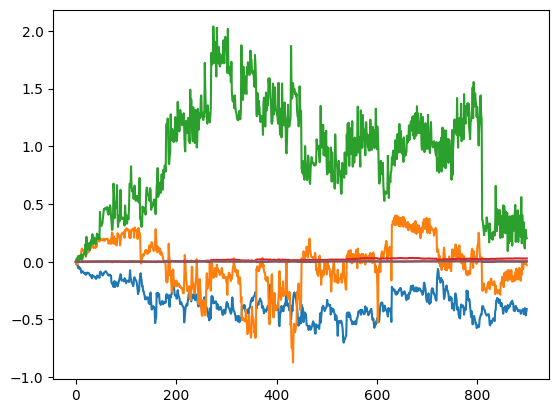

In [116]:
plt.plot(motion_all)

In [ ]:
# dm_file = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles/TestSubj_TestSess_Run1_colour_Cond.mat'
# tdm_mat = sio.loadmat(dm_file)
# tn_trs = 90 # 90 timepts
# t_tr = 3 #
# log_dir = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles'
# dm_files_ = os.listdir(log_dir)
# dm_files = [i for i in dm_files_ if '.mat' in i]
# dm_files
# print(dm_files)
# dm_conds = [str(i[0]) for i in tdm_mat['names'][0]]
# ons = {}
# dur = {}
# cond_list = []
# for iC,c in enumerate(dm_conds):
#     ons[c] = tdm_mat['onsets'][0][iC][0] # weird matlab... have to index this way
#     print(ons[c])
#     ons[c] = [int(i / t_tr) for i in ons[c]]
#     print(ons[c])
#     dur[c] = tdm_mat['durations'][0][iC][0] #int(tdm_mat['durations'][0][iC][0] // t_tr) # in trs
#     if c != 'rest':
#         cond_list.append(c)
# dmatrix = np.zeros((tn_trs, len(cond_list)))
# for iC,c in enumerate(cond_list):
#     for tonset in ons[c]:
#         # toffset = tonset+dur[c]
#         # dmatrix[tonset:toffset,iC] = 1.0
#         dmatrix[tonset,iC] = 1.0
# dur = 30 # 

# t_dmatrix_info = {
#     'dur' : dur, 
#     'cond_list' : cond_list, 
#     'ons' : ons,
#     'dmatrix' : dmatrix, 
# }

['TestSubj_TestSess_Run1_colour.mat', 'col_dm_cond.mat', 'col_dm.mat', 'TestSubj_TestSess_Run1_colour_Cond.mat']
[8.45125000e-04 2.55008815e+02]
[0, 85]
[ 45.00162958  75.01012975 165.00254796 195.00816542]
[15, 25, 55, 65]
[ 15.01033804 105.00170842 135.01069308 225.01644929]
[5, 35, 45, 75]


In [119]:
def dm_from_path(dm_path):

    tdm_mat = sio.loadmat(dm_path)
    tn_trs = 90 # 90 timepts
    t_tr = 3 #
    dm_conds = [str(i[0]) for i in tdm_mat['names'][0]]
    ons = {}
    dur = {}
    cond_list = []
    for iC,c in enumerate(dm_conds):
        ons[c] = tdm_mat['onsets'][0][iC][0] # weird matlab... have to index this way
        print(ons[c])
        ons[c] = [int(i / t_tr) for i in ons[c]]
        print(ons[c])
        dur[c] = tdm_mat['durations'][0][iC][0] #int(tdm_mat['durations'][0][iC][0] // t_tr) # in trs
        if c != 'rest':
            cond_list.append(c)
    dmatrix = np.zeros((tn_trs, len(cond_list)))
    for iC,c in enumerate(cond_list):
        for tonset in ons[c]:
            # toffset = tonset+dur[c]
            # dmatrix[tonset:toffset,iC] = 1.0
            dmatrix[tonset,iC] = 1.0
    dur = 30 # 

    t_dmatrix_info = {
        'dur' : dur, 
        'cond_list' : cond_list, 
        'ons' : ons,
        'dmatrix' : dmatrix, 
    }

    bw_vals = [(v, 'bw', i) for i, v in enumerate(ons['bw'])]
    col_vals = [(v, 'colour', i) for i, v in enumerate(ons['colour'])]

    all_vals = sorted(bw_vals + col_vals, key=lambda x: x[0])

    bw_order = [None] * len(ons['bw'])
    col_order = [None] * len(ons['colour'])

    for rank, (val, source, original_idx) in enumerate(all_vals):
        if source == 'bw':
            bw_order[original_idx] = rank
        else:
            col_order[original_idx] = rank

    beta_order = {'bw': bw_order, 'col': col_order}
    return t_dmatrix_info, beta_order
a,z= dm_from_path('/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles/TestSubj_TestSess_Run1_colour_Cond.mat')
# print('hello')
t_dmatrix_info, beta_order = dm_from_path(
    f'/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/{sub}/ses-1/func/{sub}_color-task_sess-01_run-01_conditions.mat'
)



run_indices = np.arange(len(rfiles))
splits = {
    'split0': run_indices[::2],   # interleaved: even runs
    'split1': run_indices[1::2],  # interleaved: odd runs
}

glm_paths = {}
glm_paths['full'] = opj(stest_dir,'glm_full_denoise_only')
glm_paths['split0'] = opj(stest_dir,'glm_split0_denoise_only')
glm_paths['split1'] = opj(stest_dir,'glm_split1_denoise_only')
for r in run_indices:
    glm_paths[f'run{r}'] = opj(stest_dir, f'glm_run{r}_denoised_only')

[8.45125000e-04 2.55008815e+02]
[0, 85]
[ 45.00162958  75.01012975 165.00254796 195.00816542]
[15, 25, 55, 65]
[ 15.01033804 105.00170842 135.01069308 225.01644929]
[5, 35, 45, 75]
[7.63893127e-04 2.55003765e+02]
[0, 85]
[ 75.00861907 105.00228691 165.00610995 195.016289  ]
[25, 35, 55, 65]
[ 15.00483108  45.01500988 135.0124619  225.01080394]
[5, 15, 45, 75]


In [120]:
import glmsingle
from glmsingle.glmsingle import GLM_single
import scipy
import os
import shutil
opj = os.path.join

opt = dict()
# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 0
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 0

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# opt['chunklen'] = 500
# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
tglm = GLM_single(opt)

rnib = [nib.load(f) for f in rfiles]
rdata = []
for i in range(len(rnib)):
    rdata.append(nib.load(rfiles[i]).get_fdata(dtype=np.float32))

In [ ]:
# variables that will contain bold time-series and design matrices from each run
data = []
design = []

nruns = 0
for R in range(len(rdata)):
    data.append(
        rdata[R],
        )
    design.append(t_dmatrix_info['dmatrix'])
    nruns += 1

# get shape of data volume (XYZ) for convenience
xyz = data[0].shape[:3]
xyzt = data[0].shape

# get total number of blocks - this will be the dimensionality of output betas from GLMsingle
nblocks = int(np.sum(np.concatenate(design)))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0
# run GLMsingle
if True: #not os.path.exists(glm_paths['full']):
    results_full = tglm.fit(
        design,
        data,
        stimdur,
        tr,
        outputdir=None, #glm_paths['full']
        )
else:
    bloop

In [ ]:
# brainmask = meanvol > 2500
tnruns = len(data)
tbsplit = np.array_split(results_full['typec']['betasmd'], 10, axis=-1)
betas_full = {}
for k in beta_order.keys():
    betas_full[k] = []
    for iR in range(tnruns):
        for ibeta in beta_order[k]:
            betas_full[k].append(tbsplit[iR][:,:,:,ibeta])
    betas_full[k] = np.nanmean(betas_full[k], axis=0)

tdata_full = betas_full['col'] -  betas_full['bw']
tmask_full = results_full['typec']['meanvol']>5000
tdata_full[~tmask_full] = np.nan
timg = nib.Nifti1Image(tdata_full.astype(np.float32), rnib[0].affine)

tfile_full = opj(output_full, 'colmbw_mv5000.nii.gz')
tfile_full_al = opj(output_full, 'colmbw_mv5000al.nii.gz')
nib.save(timg, tfile_full)
func2anat(tfile_full, sub)

In [ ]:
isl = 20
tdata = betas_full['bw'][:,:,isl] #np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10, :], axis=-1)
tdata =  betas_full['col'][:,:,isl] -  betas_full['bw'][:,:,isl] 
# tmask = results_full['typec']['meanvol'][:,:,isl]>4000
tdata[~tmask] = np.nan
print(np.nanmax(tdata))
#results_glmsingle['typec']['meanvol'][:,:,-10]>3200,
plt.imshow(
    tdata,
    vmin=-3, vmax=3, cmap='RdBu',
    )

In [ ]:
betas_full

## half half

In [122]:
# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0
results = {}
for split in splits.keys():

   # variables that will contain bold time-series and design matrices from each run
   tdata = []
   tdesign = []

   nruns = 0
   for R in splits[split]:
      tdata.append(
         rdata[R],
         )
      tdesign.append(t_dmatrix_info['dmatrix'])
      nruns += 1

   # get total number of blocks - this will be the dimensionality of output betas from GLMsingle

   tglm = GLM_single(opt)
   results[split] = tglm.fit(
      tdesign,
      tdata,
      stimdur,
      tr,
      outputdir=glm_paths[split])

*** DIAGNOSTICS ***:
There are 5 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8, 8, 8, 8, 8].
The number of trials for each condition is: [np.int64(20), np.int64(20)].
For each condition, the number of runs in which it appears: [np.int64(5), np.int64(5)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split0_denoise_only/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split0_denoise_only/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

f

chunks: 100%|██████████| 31/31 [00:12<00:00,  2.43it/s]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split0_denoise_only/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 31/31 [01:43<00:00,  3.33s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



...


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split1_denoise_only/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 31/31 [42:40<00:00, 82.61s/it]   



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 31/31 [01:55<00:00,  3.73s/it]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split1_denoise_only/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** All model types done ***

*** return model types in results ***



In [124]:
betas = {}
for split in splits.keys():
    tbsplit = np.array_split(results[split]['typec']['betasmd'], 5, axis=-1) # 5 because half
    betas[split] = {}
    for k in beta_order.keys():
        betas[split][k] = []
        for iR in range(5):
            for ibeta in beta_order[k]:
                betas[split][k].append(tbsplit[iR][:,:,:,ibeta])
        betas[split][k] = np.nanmean(betas[split][k], axis=0)

In [ ]:
# betas = {}
# for split in [1, 2]:
#     betas[split] = {}
#     r2 = results[split]['typec']['R2run']  # (164, 164, 50, 5)

#     # R2-weighted mean: w_i = max(R2_i, 0) to exclude negative fits
#     r2_bw  = np.maximum(r2[:, :, :, ::2],  0)   # even runs
#     r2_col = np.maximum(r2[:, :, :, 1::2], 0)   # odd runs

#     w_sum_bw  = r2_bw.sum(axis=-1,  keepdims=True)
#     w_sum_col = r2_col.sum(axis=-1, keepdims=True)

#     # Fall back to uniform weights where all R2 <= 0
#     w_bw  = np.where(w_sum_bw  > 0, r2_bw  / w_sum_bw,  1 / r2_bw.shape[-1])
#     w_col = np.where(w_sum_col > 0, r2_col / w_sum_col, 1 / r2_col.shape[-1])

#     betas[split]['bw']  = np.nansum(results[split]['typec']['betasmd'][:, :, :, ::2]  * w_bw,  axis=-1)
#     betas[split]['col'] = np.nansum(results[split]['typec']['betasmd'][:, :, :, 1::2] * w_col, axis=-1)

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
for iS,split in enumerate([1,2]):
    axs[iS].imshow(
        np.nanmean(
            results[split]['typec']['betasmd'][:,:,-10,:], axis=-1),
            vmin=-5, vmax=5, cmap='RdBu',
           )

In [ ]:
isl = -15
fig, axs = plt.subplots(1,2,figsize=(10,5))
for iS,split in enumerate([1,2]):
    tdata = betas[split]['bw'][:,:,isl] #np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10, :], axis=-1)
    tdata =  betas[split]['col'][:,:,isl] -  betas[split]['bw'][:,:,isl] 
    tmask = results[split]['typec']['meanvol'][:,:,isl]>4000
    tdata[~tmask] = np.nan
    print(np.nanmax(tdata))
    #results_glmsingle['typec']['meanvol'][:,:,-10]>3200,
    axs[iS].imshow(
        tdata,
        vmin=-3, vmax=3, cmap='RdBu',
        )
    # plt.colorbar()

In [126]:
tfile_als = {}
for split in ['split0','split1']:
    tdata = betas[split]['col'] -  betas[split]['bw']
    tmask = results[split]['typec']['meanvol']>400
    tdata[~tmask] = np.nan
    timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
    
    tfile = opj(glm_paths[split], 'colmbw_mv5000.nii.gz')
    tfile_al = opj(glm_paths[split], 'colmbw_mv5000al.nii.gz')
    tfile_als[split] = tfile_al
    nib.save(timg, tfile)
    func2anat(tfile, sub)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split0_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
-0.99857  -0.01692  -0.05065   4.70967;
-0.05176   0.07394   0.99592  -18.01352;
 0.01311  -0.99712   0.07471  -77.28967;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.00000;
 0.00000   

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 1112418 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split0_denoise_only/colmbw_mv5000.nii.gz...
 



Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.01311  -0.99712   0.07471  -77.28968;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
-0.86903  -0.04408   0.01473   229.88522;
 0.01147   0.06537   0.87248  -30.27855;
 0.04505  -0.86672   0.06434   190.77693;
 0.00000   0.00000   0.00000   1.00000;

Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split1_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
-0.99857  -0.01692  -0.05065   4.70967;
-0.05176   0.07394   0.99592  -18.01352;
 0

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 1110163 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_split1_denoise_only/colmbw_mv5000.nii.gz...
 



Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.01311  -0.99712   0.07471  -77.28968;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
-0.86903  -0.04408   0.01473   229.88522;
 0.01147   0.06537   0.87248  -30.27855;
 0.04505  -0.86672   0.06434   190.77693;
 0.00000   0.00000   0.00000   1.00000;

Resampling
Output registration matrix is identity

mri_vol2vol done


# 1 runs; 2 runs 

In [130]:
run_indices = np.arange(len(rfiles))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0
resultsNr = {}
for r in run_indices:
   # shutil.rmtree(glm_out)
   # variables that will contain bold time-series and design matrices from each run
   tdata = []
   tdesign = []

   nruns = 0
   tdata = [np.nan_to_num(rdata[r])]
   tdesign = t_dmatrix_info['dmatrix']

   # get total number of blocks - this will be the dimensionality of output betas from GLMsingle
   # nblocks = int(np.sum(np.concatenate(design)))
   opt = dict()
   # set important fields for completeness (but these would be enabled by default)
   opt['wantlibrary'] = 0
   opt['wantglmdenoise'] = 1
   opt['wantfracridge'] = 0

   # for the purpose of this example we will keep the relevant outputs in memory
   # and also save them to the disk
   opt['wantfileoutputs'] = [1,1,1,1]
   opt['wantmemoryoutputs'] = [1,1,1,1]
   tglm = GLM_single(opt)
   print(f'**********************')
   print(f'RUN {r}')
   print(f'**********************')

   resultsNr[r] = tglm.fit(
      tdesign,
      tdata,
      stimdur,
      tr,
      outputdir=glm_paths[f'run{r}'])
   # break

**********************
RUN 0
**********************
*** DIAGNOSTICS ***:
There are 1 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8].
The number of trials for each condition is: [np.int64(4), np.int64(4)].
For each condition, the number of runs in which it appears: [np.int64(1), np.int64(1)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***


/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/glmsingle/glmsingle.py:657: UserWarning: None of your conditions occur in more than one run. Are you sure this is what you intend?
  warnings.warn(msg)
/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/glmsingle/glmsingle.py:667: UserWarning: Since there are no repeats, standard cross-validation usage of <wantglmdenoise> cannot be performed. Setting <wantglmdenoise> to 0.
  warnings.warn(msg)


*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/TYPEA_ONOFF.npy. ***



/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 1.2340469092999795 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



...

*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/TYPEA_ONOFF.npy. ***



/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 1.0908444684692962 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 31/31 [00:02<00:00, 11.98it/s]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/TYPEB_FITHRF.npy. ***

*** All model types done ***

*** return model types in results ***



In [131]:
# brainmask = meanvol > 2500
betasNr = {}
beta_id = beta_order.copy()
for r in run_indices:
    betasNr[r] = {}
    for k in beta_order.keys():
        betasNr[r][k] = []
        for ibeta in beta_order[k]:
            betasNr[r][k].append(resultsNr[r]['typeb']['betasmd'][:,:,:,ibeta])
        betasNr[r][k] = np.nanmean(betasNr[r][k], axis=0)




In [132]:
# R2 MEAN
# beta_id = {'bw': [0, 3, 4, 7], 'col': [1, 2, 5, 6]}

# Per-run condition averages and R2 maps
betasNr = {}
r2Nr = {}
for r in run_indices:
    r2Nr[r] = resultsNr[r]['typeb']['R2']  # shape (X, Y, Z)
    betasNr[r] = {}
    for k, indices in beta_id.items():
        betas = np.stack(
            [resultsNr[r]['typeb']['betasmd'][..., i] for i in indices],
            axis=0
        )
        betasNr[r][k] = np.nanmean(betas, axis=0)  # shape (X, Y, Z)

# R2-weighted mean across runs
r2_stack = np.stack([r2Nr[r] for r in run_indices], axis=0)  # (n_runs, X, Y, Z)
r2_sum = np.nansum(r2_stack, axis=0)  # (X, Y, Z), avoid div-by-zero below

betasNr_full = {}
for k in beta_id:
    betas_stack = np.stack([betasNr[r][k] for r in run_indices], axis=0)  # (n_runs, X, Y, Z)
    betasNr_full[k] = np.nansum(betas_stack * r2_stack, axis=0) / np.where(r2_sum > 0, r2_sum, np.nan)

In [133]:
epi_th = 400 # 5000
tfile_al_nRs = {}
for r in run_indices:
    tdata = betasNr[r]['col'] -  betasNr[r]['bw']
    tmask = resultsNr[r]['typeb']['meanvol']>epi_th
    tdata[~tmask] = np.nan
    timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
    if not os.path.exists(glm_paths[f'run{r}']):
        os.makedirs(glm_paths[f'run{r}'])
        
    tfile = opj(glm_paths[f'run{r}'],f'colmbw_mv{epi_th}.nii.gz')
    tfile_al = opj(glm_paths[f'run{r}'], f'colmbw_mv{epi_th}al.nii.gz')
    tfile_al_nRs[r] = tfile_al
    nib.save(timg, tfile)
    func2anat(tfile,sub)


# R2w mean
tdata = betasNr_full['col'] -  betasNr_full['bw']
tmask = resultsNr[r]['typeb']['meanvol']>epi_th
tdata[~tmask] = np.nan
timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)

tfile = opj(stest_dir, f'colmbw_mv{epi_th}R2W.nii.gz')
tfile_al = opj(stest_dir, f'colmbw_mv{epi_th}R2Wal.nii.gz')
tfile_al_nRs['r2wfull'] = tfile_al
nib.save(timg, tfile)
func2anat(tfile,sub)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/colmbw_mv400.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
-0.99857  -0.01692  -0.05065   4.70967;
-0.05176   0.07394   0.99592  -18.01352;
 0.01311  -0.99712   0.07471  -77.28967;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.00000;
 0.00000   0.

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 1115179 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/colmbw_mv400.nii.gz...
 



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/colmbw_mv400.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/colmbw_mv400.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run0_denoised_only/colmbw_mv400al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774096485
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.013

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 1111764 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run1_denoised_only/colmbw_mv400.nii.gz...
 



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run1_denoised_only/colmbw_mv400.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run1_denoised_only/colmbw_mv400.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run1_denoised_only/colmbw_mv400al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774131419
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.013

...


/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run8_denoised_only/colmbw_mv400.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run8_denoised_only/colmbw_mv400.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run8_denoised_only/colmbw_mv400al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774164056
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.013

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 1114327 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/colmbw_mv400.nii.gz...
 



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/colmbw_mv400.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/colmbw_mv400.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/glm_run9_denoised_only/colmbw_mv400al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774168815
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.013

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 1114327 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/colmbw_mv400R2W.nii.gz...
 



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/colmbw_mv400R2W.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/colmbw_mv400R2W.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-ht2/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/colmbw_mv400R2Wal.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_single/sub-ht2/test01/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774154634
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
-0.99857  -0.01692  -0.05065   4.70971;
-0.05176   0.07394   0.99592  -18.01346;
 0.01311  -0.99712   0.07471  -77.28968;
 0.00000   0.00000   0.00

# combine for plotting

In [135]:
import cortex

# Force the reload

vols = {}
# vols['col_m_bwfull'] = nib.load(tfile_full_al).get_fdata().transpose(2,1,0)
for split in ['split0','split1']:
    vols[f'col_m_bwSplit{split}'] = nib.load(tfile_als[split]).get_fdata().transpose(2,1,0)
for r in run_indices:
    vols[f'col_m_bwR{r}'] = nib.load(tfile_al_nRs[r]).get_fdata().transpose(2,1,0)
vols[f'col_m_bwR2W'] = nib.load(tfile_al_nRs['r2wfull']).get_fdata().transpose(2,1,0)
vols['tsnr'] = nib.load(opj(stest_dir, f'runtsnral.nii.gz')).get_fdata().transpose(2,1,0)
vols['mepi'] = nib.load(opj(stest_dir, f'runmeanal.nii.gz')).get_fdata().transpose(2,1,0)
# mask = vols['tsnr']<10
# for k in vols.keys():
#     vols[k][mask] = np.nan
maps = {}

for v in vols.keys():
    if v not in ('tsnr', 'mepi'):        
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            vmin=-2, vmax=2,
            cmap='RdBu_r', 
        )
    else:
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            # vmin=-3, vmax=3,
            # cmap='RdBu_r'
        )



maps['b14ecc']= cortex.Vertex(
    b14_info['ecc'], sub, 
    cmap='jet', vmin=0, vmax=10, 
)
maps['b14pol']= cortex.Vertex(
    b14_info['pol'], sub, 
    cmap='hsv', vmin=0, vmax=180, 
)



In [139]:
cortex.webshow(maps, recache=True)

Generating new ctm file...
wm
wm
inflated
inflated
Started server on port 15789


<JS: window.viewer>

In [151]:
cortex.webgl.make_static(
    f'./glm_{sub}',
    maps, )

Stopping server


# direct surface - testing

In [ ]:
import cortex
import cortex.mapper
# get the mapper for your subject/transform
mapper = cortex.mapper.get_mapper(sub, xfmname='identity', type='trilinear')
surf_data = {}
for k in maps.keys():
    if k in ('b14ecc', 'b14pol'):
        surf_data[k] = maps[k].data
    else:
        surf_data[k] = mapper(maps[k]).data
tmask = (surf_data['b14ecc'] < 10) & \
    (surf_data['tsnr']>5)


In [ ]:
from dpu_mini.mesh_maker import *
import dpu_mini.pyctx_cannibalized.subsurf2 as pcx
from dpu_mini.fs_tools import *
# gm = GenMeshMaker(sub, fs_dir=fs_dir)
gm = pcx.PyctxMaker(
    sub=sub, 
    fs_dir=fs_dir, 
)
gm.add_flat_to_mesh_info_ctx()
b14_all = dag_load_roi(
    sub, 
    'b14_V',
    # ['b14_V1', 'b14_V2'], 
    combine_matches=True, fs_dir=fs_dir)
b14_all &= b14_info['ecc']<20.0
# gm.rescale_mesh_info('flat')
gm.make_flat_map(b14_all, morph=20, hemi_project='flat', flat_name='flatcut', method='none')
gm.rescale_mesh_info('flatcut')

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
plt_kwargs = dict(
    cmap='RdBu', 
    vmin=-2, vmax=2, roi_list='b14_V2', 
    hemi_list=['rh'], 
    flat_name='flatcut', 

)
gm.flat_mpl(
    data=surf_data['col_m_bw1'],
    data_mask=tmask,
    ax=axs[0], **plt_kwargs
    )
# axs[0].set_xlim(-100, 0)
# axs[0].set_aspect('equal')
gm.flat_mpl(
    data=surf_data['col_m_bw2'],
    data_mask=tmask,
    ax=axs[1], **plt_kwargs
    )


In [ ]:
mask = dag_load_roi(
    sub, 
    # 'rh.b14_V2',
    ['rh.b14_V1', 'rh.b14_V2',  'rh.b14_V3.'], 
    fs_dir=fs_dir, combine_matches=True)
# mask = dag_load_roi(sub, ['lh.b14_V2', ], fs_dir=fs_dir, combine_matches=True)
mask = dag_morph_roi(gm, mask, morph=2)
print(mask.sum())




In [ ]:
import scipy as sp
sm = gm.return_pyc_sm(mask=mask, hemi='rh', surf='pial')
B, D, W, V = sm.laplace_operator
npt = W.shape[0]
Dinv = sp.sparse.dia_matrix((D**-1, [0]), (npt, npt)).tocsr()
L = Dinv.dot((V - W))
nmodes = 200
eigenvalues, eigenvectors = sp.sparse.linalg.eigs(-L, k=nmodes, which="LM", sigma=0)
# Sort ascending by eigenvalue
idx = np.argsort(eigenvalues.real)
eigenvalues = eigenvalues.real[idx]      # (200,) — index 0 is DC (λ≈0)
eigenvalues[0] = 0
eigenvectors = eigenvectors.real[:, idx] # (npt, 200)
eigenvectors[:,-1] = 1
# Now get spatial frequency from gd + eigenvectors

sf = np.sqrt(np.abs(eigenvalues))/(np.pi*2)


In [ ]:
gd = dag_pairwise_geodesic_distance(
    gm.mesh_info['pial']['rh'], mask[gm.n_vx['lh']:])

In [ ]:
def autocorrelogram_frequency(phi, D, n_bins=100, n_freqs=500, max_dist=None):
    N = len(phi)
    if max_dist is None:
        max_dist = np.percentile(D[D > 0], 90)

    # Compute autocorrelogram
    i_idx, j_idx = np.triu_indices(N, k=1)
    dists = D[i_idx, j_idx]
    products = phi[i_idx] * phi[j_idx]

    bins = np.linspace(0, max_dist, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    R = np.array([products[np.digitize(dists, bins) - 1 == b].mean() 
                  for b in range(n_bins)])

    # Grid search: dot R against candidate cosines
    f_grid = np.linspace(0, 1/bin_centers[1], n_freqs)  # max freq ~ Nyquist of bin spacing
    cosines = np.cos(2 * np.pi * f_grid[:, None] * bin_centers[None, :])  # (n_freqs, n_bins)
    power = cosines @ R  # (n_freqs,)

    best_f = f_grid[np.argmax(power)]
    return best_f, bin_centers, R, f_grid, power

In [ ]:
best_f, bin_centers, R, f_grid, power = autocorrelogram_frequency(
    eigenvectors, gd, 
)

In [ ]:
plt.scatter(
    gd[-1,:], 
    eigenvectors[:,0], 
)

In [ ]:

def get_z_fit(z, Phi, ):
    coeffs, _, _, _ = np.linalg.lstsq(Phi, z, rcond=None)
    z_fit = Phi @ coeffs
    ss_res = np.sum((z - z_fit) ** 2)
    ss_tot = np.sum((z - np.mean(z)) ** 2)
    print(f"R²: {1 - ss_res/ss_tot:.4f}")
    return z_fit, coeffs


zf, coef = get_z_fit(
    surf_data['col_m_bw1'][mask], eigenvectors
)
# coef[:20] = 0 
coef[190:] = 0 
zf2 = eigenvectors @ coef
coef

In [ ]:
coef

In [ ]:
surf_data.keys()

In [ ]:
plt.scatter(
    sf, np.abs(coef)
)

In [ ]:
gm.flat_mpl(
    data=zf2, #surf_data['col_m_bw1'][mask], 
    data_sub_mask=mask, 
    flat_name='flatcut', 
    # vmin=-3, vmax=3, 
    # vmin=-.1, vmax=.1, 
    cmap='RdBu_r', 
    roi_list=['b14_V1', 'b14_V2']
)

In [ ]:
gm.flat_mpl(
    # data=eigenvectors.real[:,-20], #
    data=geo_dists[iS,:],
    data_sub_mask=mask, 
    flat_name='flatcut'
)

In [ ]:
# For each mode, bin the product φ(x)*φ(y) by geodesic distance
# max_dist = 30.0    # mm — beyond this correlation is noise
nbins = 500
bin_edges = np.linspace(0, 500, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

wavelengths = np.zeros(nmodes)

for k in range(nmodes):
    phi = eigenvectors[:, k]          # (npt,)
    phi_seeds = phi[seed_verts]       # (n_sample,)
    phi_all   = phi[np.newaxis, :]    # (1, npt)
    
    # product at each (seed, target) pair: (n_sample, npt)
    products = phi_seeds[:, np.newaxis] * phi_all
    
    # bin by geodesic distance
    corr = np.zeros(nbins)
    counts = np.zeros(nbins)
    bin_idx = np.digitize(geo_dists, bin_edges) - 1
    valid = (bin_idx >= 0) & (bin_idx < nbins)
    
    np.add.at(corr,   bin_idx[valid], products[valid])
    np.add.at(counts, bin_idx[valid], 1)
    corr /= np.maximum(counts, 1)
    
    # normalize so corr[0] ≈ 1
    corr /= np.abs(corr).max() + 1e-12
    
    # find first zero-crossing → half-wavelength
    sign_changes = np.where(np.diff(np.sign(corr)))[0]
    if len(sign_changes) > 0:
        wavelengths[k] = 2 * bin_centers[sign_changes[0]]  # full wavelength
    else:
        wavelengths[k] = np.nan

cycles_per_mm = 1.0 / wavelengths


In [ ]:
cycles_per_mm

In [ ]:
# for i, sv in enumerate(seed_verts):
#     geo_dists[i] = trimesh.graph.vertex_geodesics(mesh, [sv])

# # For each mode, bin the product φ(x)*φ(y) by geodesic distance
# max_dist = 30.0    # mm — beyond this correlation is noise
# nbins = 100
# bin_edges = np.linspace(0, max_dist, nbins + 1)
# bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# # for i, sv in enumerate(seed_verts):
# #     geo_dists[i] = trimesh.graph.vertex_geodesics(mesh, [sv])
    
# #     # For each mode, bin the product φ(x)*φ(y) by geodesic distance
# #     max_dist = 30.0    # mm — beyond this correlation is noise
# #     nbins = 100
# #     bin_edges = np.linspace(0, max_dist, nbins + 1)
# #     bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
# #     wavelengths = np.zeros(n_modes)
    
# #     for k in range(n_modes):
# #         phi = eigenvectors[:, k]          # (npt,)
# #         phi_seeds = phi[seed_verts]       # (n_sample,)
# #         phi_all   = phi[np.newaxis, :]    # (1, npt)
        
# #         # product at each (seed, target) pair: (n_sample, npt)
# #         products = phi_seeds[:, np.newaxis] * phi_all
        
# #         # bin by geodesic distance
# #         corr = np.zeros(nbins)
# #         counts = np.zeros(nbins)
# #         bin_idx = np.digitize(geo_dists, bin_edges) - 1
# #         valid = (bin_idx >= 0) & (bin_idx < nbins)
        
# #         np.add.at(corr,   bin_idx[valid], products[valid])
# #         np.add.at(counts, bin_idx[valid], 1)
# #         corr /= np.maximum(counts, 1)
        
# #         # normalize so corr[0] ≈ 1
# #         corr /= np.abs(corr).max() + 1e-12
        
# #         # find first zero-crossing → half-wavelength
# #         sign_changes = np.where(np.diff(np.sign(corr)))[0]
# #         if len(sign_changes) > 0:
# #             wavelengths[k] = 2 * bin_centers[sign_changes[0]]  # full wavelength
# #         else:
# #             wavelengths[k] = np.nan
    
# #     cycles_per_mm = 1.0 / wavelengths
# #     return cycles_per_mm, wavelengths, bin_centers, corr  # last two for diagnostics



In [ ]:
gm.flat_mpl(
    data=geo_dists[0,:], 
    data_sub_mask=mask, 
    flat_name='flatcut'
)

In [ ]:
npt

In [ ]:
sm.geodesic_distance(i, m=100).shape

In [ ]:
seed_verts

In [ ]:

def get_z_fit(z):
    Phi = eigenvectors[:, 1:]                          # drop DC mode → (npt, 199)
    Phi = np.hstack([np.ones((npt, 1)), Phi])          # add explicit bias → (npt, 200)
    coeffs, _, _, _ = np.linalg.lstsq(Phi, z, rcond=None)
    z_fit = Phi @ coeffs
    ss_res = np.sum((z - z_fit) ** 2)
    ss_tot = np.sum((z - np.mean(z)) ** 2)
    print(f"R²: {1 - ss_res/ss_tot:.4f}")
    return z_fit, coeffs

z_fit = {}
z_fit[1], coeff1 = get_z_fit(z=surf_data['col_m_bw1'][mask])
z_fit[2], coeff2 = get_z_fit(z=surf_data['col_m_bw2'][mask])


In [ ]:
geo_dists

In [ ]:

def plot_power_spectrum(coeffs_list, labels, eigenvalues, colors=None):
    """eigenvalues: sorted real array including DC at index 0"""
    eigs_no_dc = eigenvalues[1:]                                        # (199,)
    spatial_freq = np.sqrt(np.abs(eigs_no_dc)) / (2 * np.pi)           # cycles/mm

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    nbins = 50
    bin_edges = np.linspace(spatial_freq.min(), spatial_freq.max(), nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for i, (coeffs, label) in enumerate(zip(coeffs_list, labels)):
        c = coeffs[1:]                  # drop bias → (199,), matches eigs_no_dc
        power = c ** 2

        col = colors[i] if colors else None
        axes[0].semilogy(eigs_no_dc, power, label=label, alpha=0.8, color=col)

        bin_power = np.array([
            power[(spatial_freq >= bin_edges[b]) & (spatial_freq < bin_edges[b+1])].sum()
            for b in range(nbins)
        ])
        axes[1].semilogy(bin_centers, bin_power + 1e-12, label=label, alpha=0.8, color=col)

    axes[0].set_xlabel('Eigenvalue λ (1/mm²)')
    axes[0].set_ylabel('Power (coeff²)')
    axes[0].set_title('Power vs eigenvalue')
    axes[0].legend()

    axes[1].set_xlabel('Spatial frequency (cycles/mm)')
    axes[1].set_ylabel('Power (summed in bin)')
    axes[1].set_title('Power spectrum (cycles/mm)')
    axes[1].legend()

    plt.tight_layout()
    return fig, axes

fig, axes = plot_power_spectrum(
    coeffs_list=[coeff1, coeff2],
    labels=['bw1', 'bw2'],
    eigenvalues=eigenvalues,
    colors=['steelblue', 'tomato']
)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_power_spectrum(coeffs_list, labels, eigenvalues, colors=None):
    """
    coeffs_list : list of coeff arrays (one per condition), first coeff is bias
    eigenvalues : real part, length k (excluding DC, matching Phi[:,1:])
    """
    freqs_eig = eigenvalues.real[1:]          # drop DC eigenvalue (≈0)
    spatial_freq = np.sqrt(np.abs(freqs_eig)) / (2 * np.pi)   # cycles/mm

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for i, (coeffs, label) in enumerate(zip(coeffs_list, labels)):
        c = coeffs[1:]                         # drop bias coeff
        power = c ** 2                         # raw power per mode

        col = colors[i] if colors else None

        # --- Left: power vs eigenvalue index ---
        axes[0].semilogy(power, label=label, alpha=0.8, color=col)

        # --- Right: power vs cycles/mm (binned for readability) ---
        # bin into ~50 frequency bands
        nbins = 50
        bin_edges = np.linspace(spatial_freq.min(), spatial_freq.max(), nbins+1)
        bin_power = np.zeros(nbins)
        for b in range(nbins):
            in_bin = (spatial_freq >= bin_edges[b]) & (spatial_freq < bin_edges[b+1])
            bin_power[b] = power[in_bin].sum()
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        axes[1].semilogy(bin_centers, bin_power, label=label, alpha=0.8, color=col)

    axes[0].set_xlabel('Eigenvector index')
    axes[0].set_ylabel('Power (coeff²)')
    axes[0].set_title('Power spectrum (by mode index)')
    axes[0].legend()

    axes[1].set_xlabel('Spatial frequency (cycles/mm)')
    axes[1].set_ylabel('Power (summed in bin)')
    axes[1].set_title('Power spectrum (cycles/mm)')
    axes[1].legend()

    plt.tight_layout()
    return fig, axes

fig, axes = plot_power_spectrum(
    coeffs_list=[coeff1[1:], coeff2[1:]],
    labels=['bw1', 'bw2'],
    eigenvalues=eigenvalues.real[1:],   # already excludes DC
    colors=['steelblue', 'tomato']
)
plt.show()

In [ ]:
eigenvalues.real

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
plot_kwargs = dict(
    # 
    flat_name='flatcut', 
    vmin=-1, vmax=1, 
    cmap='RdBu', hemi_list=['rh'], 
    roi_list=['b14_V1', 'b14_V2']

)
for i,k in enumerate([1,2]):
    gm.flat_mpl(
        data=z_fit[k],
        data_sub_mask=mask, 
        # data=surf_data[f'col_m_bw{k}'],
        ax=axs[i], 
        **plot_kwargs
    )
    axs[i].set_xlim(0,100)
    axs[i].set_aspect(1)

## old

In [ ]:
# Get m
# meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
r2_th = results_glmsingle['typeb']['R2'] #>20
# brainmask = meanvol > 2500
beta_id = {
    'bw' : [0,3,4,7],
    'col':[1,2,5,6],
}
betas = {}
for k in beta_id.keys():
    betas[k] = []
    for i in beta_id[k]:
        betas[k].append(results_glmsingle['typec']['betasmd'][:,:,:,i])
    betas[k] = np.nanmean(betas[k], axis=0)

# bth = betas.copy()
# for k in bth.keys():
    
#     bth[k][~brainmask] = np.nan
#     bth[k][~r2_th] = np.nan


In [ ]:
plt.imshow(betas['bw'][:,:,25]-betas['col'][:,:,25])

In [ ]:
plt.imshow(
    # betas['bw'][:,:,-10],
    np.nanmean(results_glmsingle['typed']['betasmd'][:,:,-10,:], axis=-1),
    vmin=-5, vmax=5, cmap='RdBu',
    # vmin=0, vmax=1,
           )

In [ ]:
isl = -15
tdata = betas['bw'][:,:,isl] #np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10, :], axis=-1)
tdata =  betas['col'][:,:,isl] -  betas['bw'][:,:,isl] 
tmask = results_glmsingle['typed']['meanvol'][:,:,isl]>4000
tdata[~tmask] = np.nan
print(np.nanmax(tdata))
#results_glmsingle['typec']['meanvol'][:,:,-10]>3200,
plt.imshow(
    # betas['bw'][:,:,-10],
    tdata,
    vmin=-3, vmax=3, cmap='RdBu',
    # vmin=0, vmax=1,
           )
plt.colorbar()

In [ ]:
tdata = betas['col'] -  betas['bw']
tmask = results_glmsingle['typec']['meanvol']>5000
tdata[~tmask] = np.nan
timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
tfile = opj(outputdir_glmsingle, 'colmbw_mv5000.nii.gz')
tfile_al = opj(outputdir_glmsingle, 'colmbw_mv5000al.nii.gz')

nib.save(timg, tfile)
func2anat(tfile)

In [ ]:
import cortex
vols = {}
vols['col_m_bw'] = nib.load(tfile_al).get_fdata().transpose(2,1,0)
vols['tsnr'] = nib.load(opj(stest_dir, f'runtsnral.nii.gz')).get_fdata().transpose(2,1,0)
vols['mepi'] = nib.load(opj(stest_dir, f'runmeanal.nii.gz')).get_fdata().transpose(2,1,0)

maps = {}
maps['col_m_bw'] = cortex.Volume(
    vols['col_m_bw'], sub, xfmname='identity',
    vmin=-3, vmax=3,
    cmap='RdBu_r'
)


for v in vols.keys():
    if v not in ('tsnr', 'mepi'):        
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            vmin=-3, vmax=3,
            cmap='RdBu_r'
        )
    else:
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            vmin=-3, vmax=3,
            cmap='RdBu_r'
        )



maps['b14ecc']= cortex.Vertex(
    b14_info['ecc'], sub, 
    cmap='jet', vmin=0, vmax=10, 
)
maps['b14pol']= cortex.Vertex(
    b14_info['pol'], sub, 
    cmap='hsv', vmin=0, vmax=180, 
)



In [ ]:

cortex.webshow(maps)